# **Stroke Disease Prediction Using Decision Tree Classification**

## Import necessary libraries

In [100]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

## Import the dataset

In [101]:
# Read the dataset
data = pd.read_csv("healthcare-dataset-stroke-data.csv")
# Display the first few rows to inspect the data
print(data.head())

      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-employed          Rural             174.12  24.0     never smoked   

   stroke  
0       1  
1       1  
2       1  
3       1  
4       1  


## Data Exploration and Visualization

In [102]:
# Get basic info
print("\nDataset Info:")
print(data.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB
None


#### *Observations*
- The dataset contains **5110 entries** and **12 columns**.  
- **Target column**: `stroke` (binary: 0 = no stroke, 1 = stroke).  
- **Numerical features**: `age`, `avg_glucose_level`.
- **Categorical features**: `gender`, `ever_married`, `work_type`, `Residence_type`, `smoking_status`.  
- Other integer features: `hypertension`, `heart_disease`.  
- No missing values in most columns, except for `bmi` (4909 non-null). 


In [103]:
# Check skewness of BMI
bmi_skew = data['bmi'].skew()
print(f"Skewness of BMI: {bmi_skew:.2f}")

Skewness of BMI: 1.06


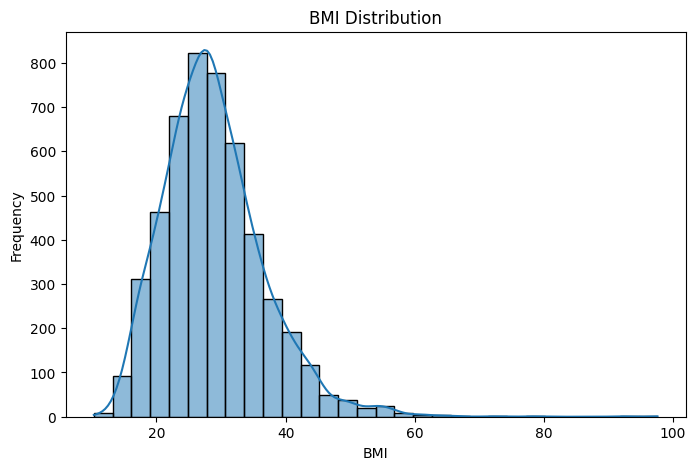

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(data['bmi'], kde=True, bins=30)
plt.title('BMI Distribution')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.show()


#### *Observation*
- The skewness of the `bmi` feature is **1.06**, which indicates a **moderate right-skew**

In [105]:
# Check for duplicate rows
duplicates = data.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


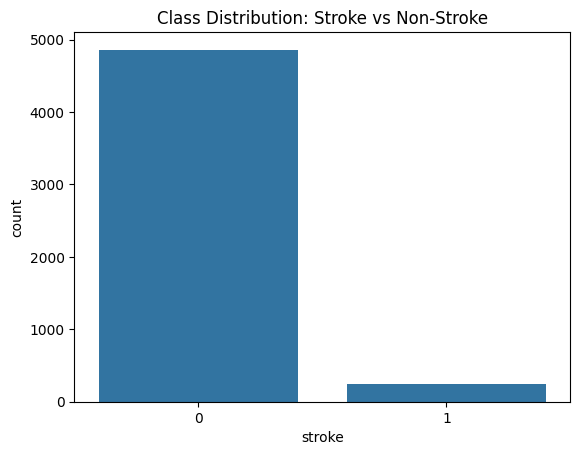

stroke
0    0.951272
1    0.048728
Name: proportion, dtype: float64


In [106]:
sns.countplot(x='stroke', data=data)
plt.title("Class Distribution: Stroke vs Non-Stroke")
plt.show()
print(data['stroke'].value_counts(normalize=True))

#### *Target Variable Observation*

- The `stroke` column is highly **imbalanced/skewed**.  
- **95.13%** of the samples correspond to **no stroke (0)**, while only **4.87%** correspond to **stroke (1)**.  
- Special care may be needed during modeling to avoid bias toward the majority class.


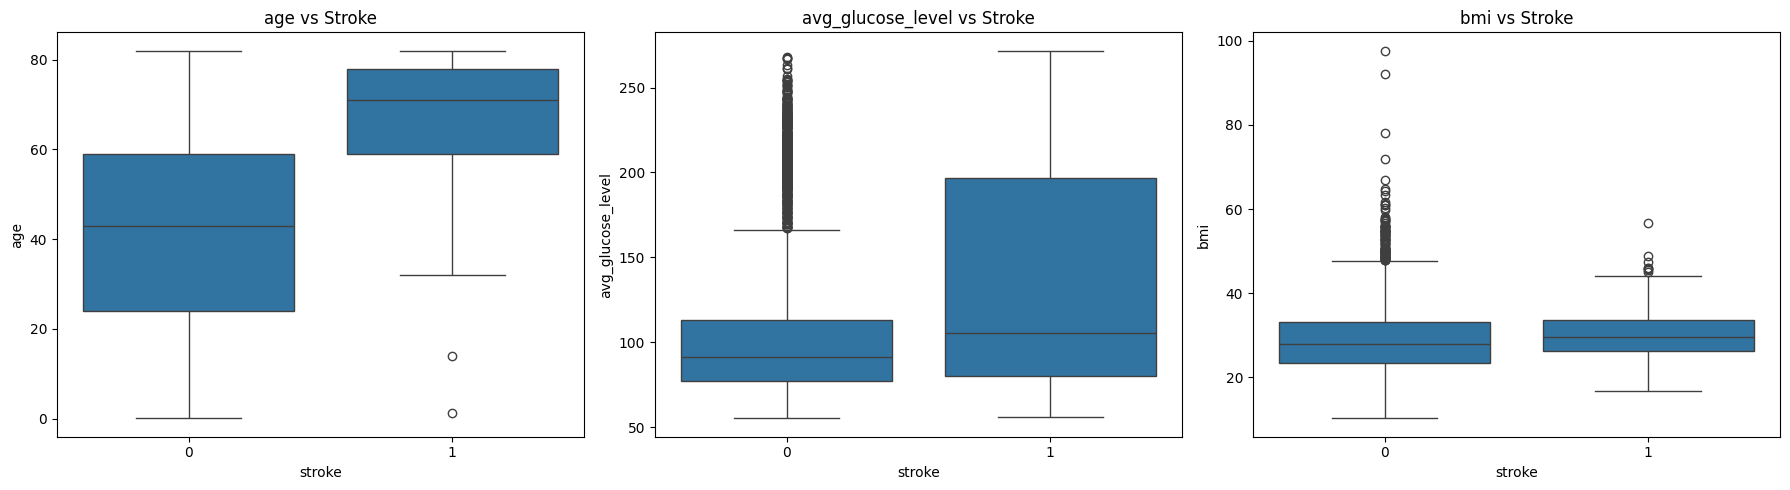

In [107]:
num_cols = ['age', 'avg_glucose_level','bmi']

# Create subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, len(num_cols), figsize=(18, 5))

for i, col in enumerate(num_cols):
    sns.boxplot(x='stroke', y=col, data=data, ax=axes[i])
    axes[i].set_title(f'{col} vs Stroke')

plt.tight_layout()
plt.show()

#### *Observation from Numeric Features vs Stroke*

- The **median age** of individuals who experienced a stroke is significantly higher than those who did not, suggesting a **strong potential correlation between age and stroke risk**. The **wider whiskers** for non-stroke individuals indicate **more variability in age** among this group.  

- The **average glucose level** for stroke patients shows a **noticeably higher median** compared to non-stroke individuals, indicating a **potential association between elevated glucose levels and stroke occurrence**. There is also **higher variability in glucose levels** among stroke patients.  

- The **median BMI** for individuals with a stroke is slightly higher than for those without, suggesting a **potential weak association** between BMI and stroke risk.


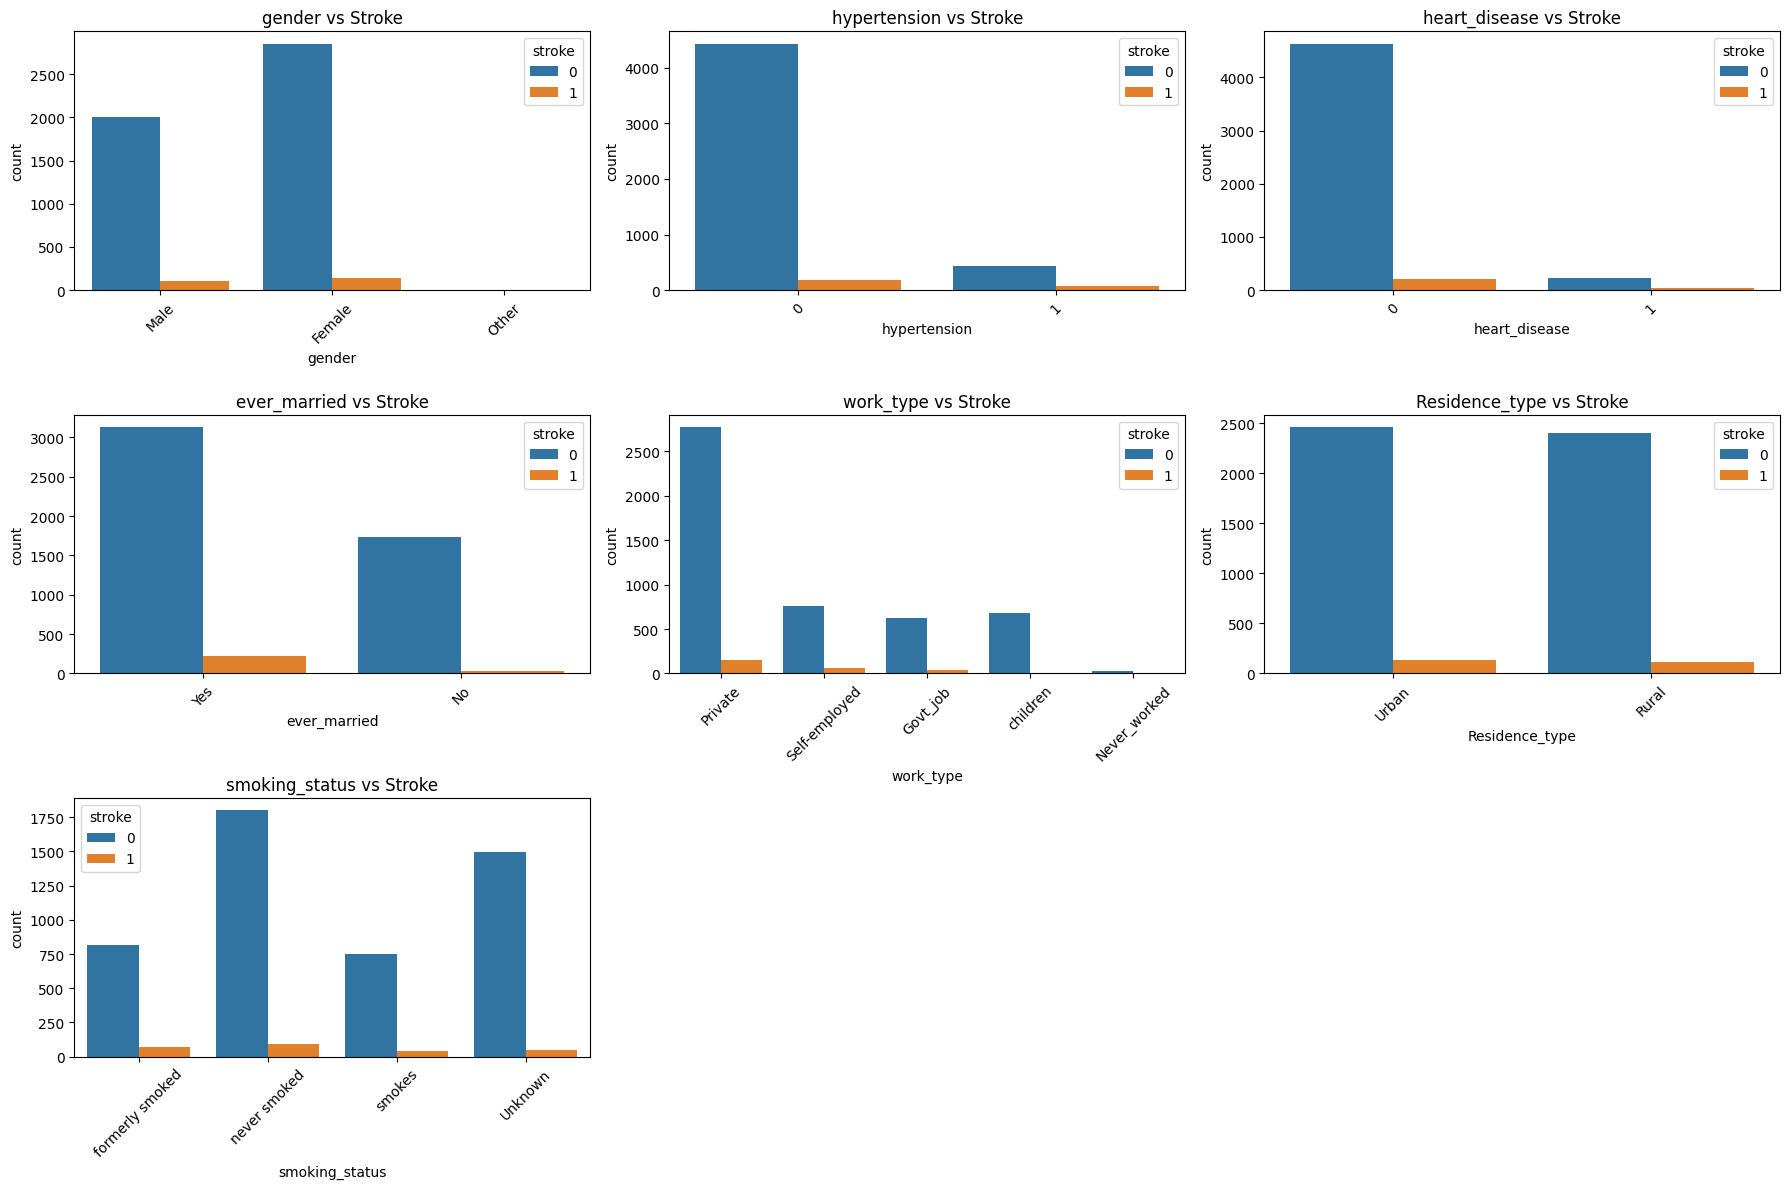

In [108]:
cat_cols = ['gender', 'hypertension', 'heart_disease', 'ever_married', 
            'work_type', 'Residence_type', 'smoking_status']

# Determine number of rows and columns for subplots
n_cols = 3
n_rows = (len(cat_cols) + n_cols - 1) // n_cols  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*4))

for i, col in enumerate(cat_cols):
    row = i // n_cols
    col_pos = i % n_cols
    sns.countplot(x=col, hue='stroke', data=data, ax=axes[row, col_pos])
    axes[row, col_pos].set_title(f'{col} vs Stroke')
    axes[row, col_pos].tick_params(axis='x', rotation=45)

# Remove empty subplots if any
for j in range(i+1, n_rows*n_cols):
    fig.delaxes(axes.flatten()[j])

plt.tight_layout()
plt.show()

## Observations from Categorical Features vs Stroke

- The proportion of stroke is **slightly higher among females** compared to males.  
- Stroke occurrence is **higher for individuals with no hypertension**.  
- Stroke occurrence is **higher for individuals with no heart disease**, suggesting other factors contribute to stroke risk.  
- There is a **higher count of strokes among married individuals** compared to unmarried ones.  
- Individuals **working in private sectors** show the highest stroke counts, followed by **self-employed** and **government employees**.  
- Those **never employed or children** show the highest counts of non-stroke cases.  
- Stroke counts are **slightly higher in urban areas** compared to rural areas, indicating a weak association with residence type.  
- Regarding smoking status, the **highest count of strokes is among never smokers**, followed by formerly smokers.

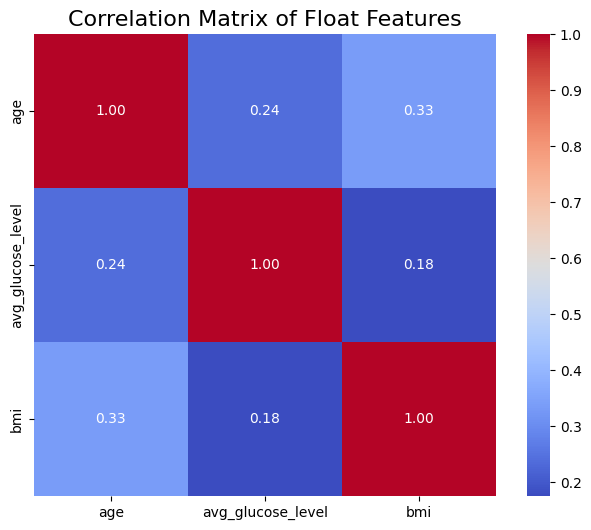

In [109]:
# Select only float columns
float_cols = data.select_dtypes(include='float').columns

# Compute correlation matrix for float columns
corr = data[float_cols].corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, square=True)
plt.title('Correlation Matrix of Float Features', fontsize=16)
plt.show()


#### *Observation from Float Feature Correlation*

- The correlation matrix of continuous numeric features (`age`, `avg_glucose_level`, `bmi`) shows **weak linear associations**.  
- No correlation value exceeds **0.5** or is less than **-0.5**, suggesting **no strong linear relationship** between these features.  
- This indicates that the features are **largely independent**, and there is **no redundant information** among them for the model.  
- Therefore, all these float features can be **retained for modeling**, as each may contribute unique information to stroke prediction.


## Data Preprocessing

In [110]:
# Fill missing BMI values with median (future-proof way)
median_bmi = data['bmi'].median()
data['bmi'] = data['bmi'].fillna(median_bmi)

# Verify
print(f"Number of missing BMI values after filling: {data['bmi'].isnull().sum()}")


Number of missing BMI values after filling: 0


#### *Handling Missing BMI Values*

- The `bmi` column had some missing values.  
- Since the BMI distribution is **right-skewed** (skewness = 1.06), we **fill missing values with the median** rather than the mean.  
- Using the median is preferred for skewed data because it is **less affected by extreme values** and better represents the central tendency of the majority of the data.
- Didn’t eliminate the records due to dataset being highly skewed on the target attribute – stroke and a good portion of the missing BMI values had accounted for positive stroke cases.


In [111]:
# Drop the 'id' column
data = data.drop(columns=['id'])
# Verify
print(data.head())


   gender   age  hypertension  heart_disease ever_married      work_type  \
0    Male  67.0             0              1          Yes        Private   
1  Female  61.0             0              0          Yes  Self-employed   
2    Male  80.0             0              1          Yes        Private   
3  Female  49.0             0              0          Yes        Private   
4  Female  79.0             1              0          Yes  Self-employed   

  Residence_type  avg_glucose_level   bmi   smoking_status  stroke  
0          Urban             228.69  36.6  formerly smoked       1  
1          Rural             202.21  28.1     never smoked       1  
2          Rural             105.92  32.5     never smoked       1  
3          Urban             171.23  34.4           smokes       1  
4          Rural             174.12  24.0     never smoked       1  


#### *Dropping the ID Column*

- The `id` column is a unique identifier for each record and **does not provide any predictive information** for stroke classification.  
- Therefore, it has been **dropped from the dataset** to simplify modeling and avoid unnecessary features.


In [112]:
# Count occurrences of each gender category
gender_counts = data['gender'].value_counts()
print(gender_counts)

# Specifically check "Other"
other_count = gender_counts.get('Other', 0)
print(f'Number of "Other" entries in gender: {other_count}')


gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64
Number of "Other" entries in gender: 1


In [113]:
# Replace "Other" with "Female"
data['gender'] = data['gender'].replace('Other', 'Female')

# Verify
print(data['gender'].value_counts())


gender
Female    2995
Male      2115
Name: count, dtype: int64


#### *Handling "Other" Gender Category*

- The `gender` column had **1 entry labeled "Other"**, which is negligible compared to the total dataset.  
- To reduce dimensionality and simplify modeling, this entry was **replaced with the majority category, "Female"**.  
- This ensures the dataset remains consistent without introducing an extra, nearly empty category.


y no col dropped

In [114]:
# Select object-type columns
cat_cols = data.select_dtypes(include='object').columns

# Print unique values for each categorical column
for col in cat_cols:
    print(f"{col} unique values: {data[col].unique()}\n")


gender unique values: ['Male' 'Female']

ever_married unique values: ['Yes' 'No']

work_type unique values: ['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']

Residence_type unique values: ['Urban' 'Rural']

smoking_status unique values: ['formerly smoked' 'never smoked' 'smokes' 'Unknown']



In [115]:
# Verify
print(data['smoking_status'].value_counts())


smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64


In [116]:
# Create a copy of the data to avoid altering the original directly
df = data.copy()

# Label Encoding for binary columns
label_cols = ['gender', 'ever_married', 'Residence_type']
le = LabelEncoder()

for col in label_cols:
    df[col] = le.fit_transform(df[col])

# One-Hot Encoding for multi-category columns
onehot_cols = ['work_type', 'smoking_status']
df = pd.get_dummies(df, columns=onehot_cols, drop_first=False)

# Check the new structure
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   gender                          5110 non-null   int32  
 1   age                             5110 non-null   float64
 2   hypertension                    5110 non-null   int64  
 3   heart_disease                   5110 non-null   int64  
 4   ever_married                    5110 non-null   int32  
 5   Residence_type                  5110 non-null   int32  
 6   avg_glucose_level               5110 non-null   float64
 7   bmi                             5110 non-null   float64
 8   stroke                          5110 non-null   int64  
 9   work_type_Govt_job              5110 non-null   bool   
 10  work_type_Never_worked          5110 non-null   bool   
 11  work_type_Private               5110 non-null   bool   
 12  work_type_Self-employed         51

#### *Encoding Summary*

Categorical variables were encoded to make them suitable for machine learning algorithms:

- **Label Encoding** was applied to binary categorical columns:
  - `gender` → Male=0, Female=1  
  - `ever_married` → No=0, Yes=1  
  - `Residence_type` → Rural=0, Urban=1  
  Label encoding was chosen because these variables have only two distinct categories.  
  In Decision Trees, label encoding does **not impose any ordinal meaning** since the model splits data based on thresholds, not numeric order.

- **One-Hot Encoding** was applied to multi-category columns:
  - `work_type` (Private, Self-employed, Govt_job, children, Never_worked)
  - `smoking_status` (formerly smoked, never smoked, smokes, Unknown)
  Although Decision Trees can handle label-encoded categories, **one-hot encoding was preferred here for interpretability** — it makes it easier to identify which specific categories have stronger influence on the target variable.

After encoding, the dataset became fully numerical and ready for model training.


## Train–Validation–Test Split

In [117]:
# Define features (X) and target (y)
X = df.drop('stroke', axis=1)   # Dropping target variable
y = df['stroke']                # Target variable (binary: 0 = No Stroke, 1 = Stroke)

# Check initial shapes
print(X.shape)
print(y.shape)

# Split df into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"X_train: {len(X_train)}")
print(f"X_test: {len(X_test)}")

# Further split training df into training and validation sets (80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)
print(f"X_train: {len(X_train)}")
print(f"X_val: {len(X_val)}")


(5110, 17)
(5110,)
X_train: 4088
X_test: 1022
X_train: 3270
X_val: 818


#### *Train–Validation–Test Split*

#### *Purpose*
- The **training set** is used to train the model and help it learn relationships between features and the target variable.  
- The **validation set** is used to fine-tune hyperparameters and evaluate model performance during training.  
- The **test set** is used only once — at the end — to assess how well the final model generalizes to unseen data.  

##### *Details*
- An **80% / 20% split** is first applied to divide the dataset into training and testing sets.  
- Then, within the training data, another **80% / 20% split** creates a **validation set**.  
- The parameter **`stratify=y`** ensures that the proportions of stroke and non-stroke cases remain consistent across all subsets.  
  This is especially important for **imbalanced datasets** like this one, as it prevents bias and ensures each subset fairly represents the original data distribution.  
